Dataset Loaded Successfully
Training Shape : (50000, 32, 32, 3)
Testing Shape : (10000, 32, 32, 3)


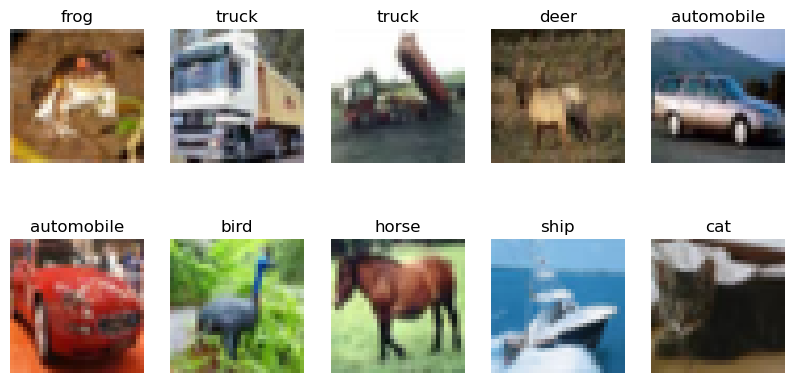


Hyperparameters Used
Learning Rate : 0.001
Dropout Rate  : 0.5
Batch Size    : 32
Epochs        : 10
Filter Size   : (3, 3)

Model Summary


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.3763 - loss: 1.6772 - val_accuracy: 0.5135 - val_loss: 1.3429
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5257 - loss: 1.3191 - val_accuracy: 0.5636 - val_loss: 1.2405
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.5820 - loss: 1.1773 - val_accuracy: 0.5929 - val_loss: 1.1224
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.6198 - loss: 1.0777 - val_accuracy: 0.6267 - val_loss: 1.0574
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6489 - loss: 0.9984 - val_accuracy: 0.6487 - val_loss: 1.0009
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6734 - loss: 0.9320 - val_accuracy: 0.6819 - val_loss: 0.9220
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6912 - loss: 0.8802 - val_accuracy: 0.6697 - val_loss: 0.9615
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7122 - loss:

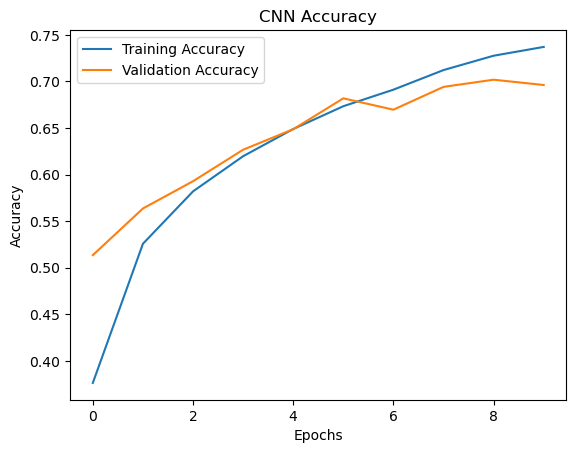

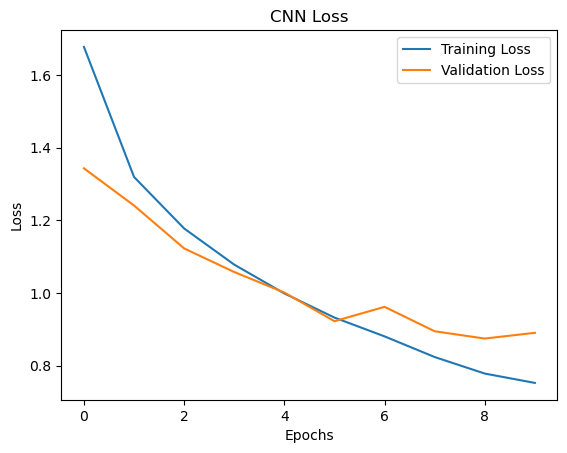

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6972 - loss: 0.8896

 0.6972000002861023
Test Loss     : 0.8895823359489441
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step   


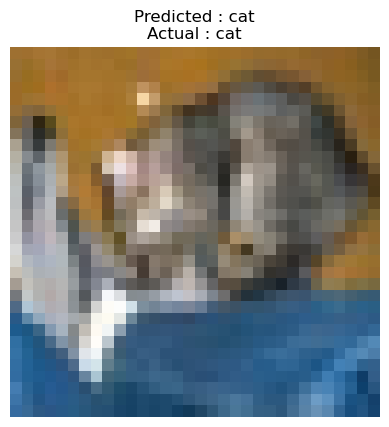

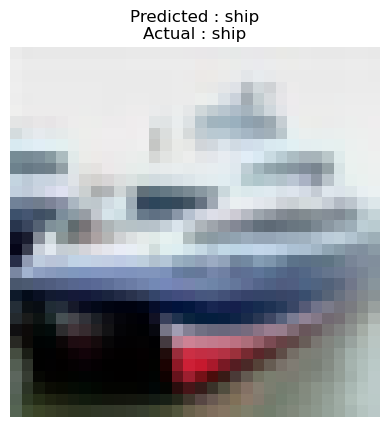

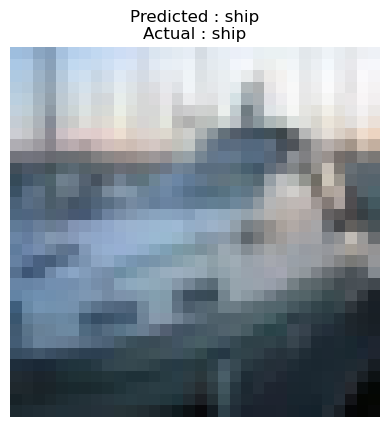

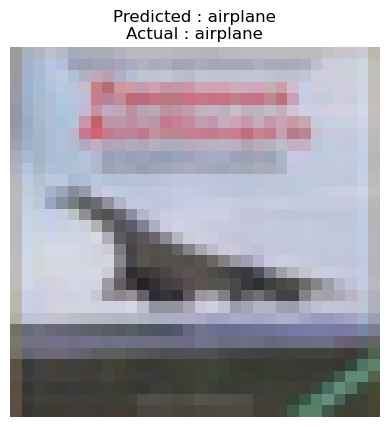

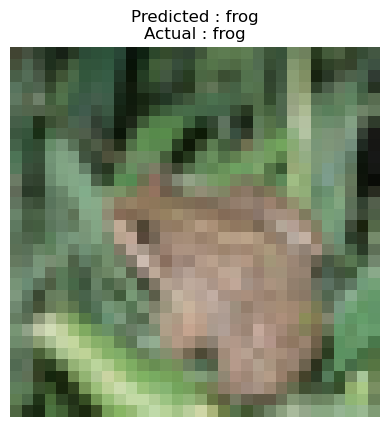


Model Saved Successfully


In [2]:
# ---------------------------------------------------------
# CNN FOR IMAGE CLASSIFICATION USING CIFAR-10 DATASET
# WITH HYPERPARAMETER TUNING AND VISUALIZATION
# ---------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ---------------------------------------------------------
# Step 1 : Load Dataset
# ---------------------------------------------------------

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Dataset Loaded Successfully")
print("Training Shape :", x_train.shape)
print("Testing Shape :", x_test.shape)

# Normalize Images
x_train = x_train / 255.0
x_test = x_test / 255.0

# Class Labels
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# ---------------------------------------------------------
# Step 2 : Display Sample Images
# ---------------------------------------------------------

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

# ---------------------------------------------------------
# Step 3 : Hyperparameters
# ---------------------------------------------------------

learning_rate = 0.001
dropout_rate = 0.5
batch_size = 32
epochs = 10
filter_size = (3,3)

print("\nHyperparameters Used")
print("Learning Rate :", learning_rate)
print("Dropout Rate  :", dropout_rate)
print("Batch Size    :", batch_size)
print("Epochs        :", epochs)
print("Filter Size   :", filter_size)

# ---------------------------------------------------------
# Step 4 : Build CNN Model
# ---------------------------------------------------------

model = Sequential()

# Convolution Layer 1
model.add(Conv2D(
    filters=32,
    kernel_size=filter_size,
    activation='relu',
    input_shape=(32,32,3)
))
model.add(MaxPooling2D((2,2)))

# Convolution Layer 2
model.add(Conv2D(
    filters=64,
    kernel_size=filter_size,
    activation='relu'
))
model.add(MaxPooling2D((2,2)))

# Convolution Layer 3
model.add(Conv2D(
    filters=128,
    kernel_size=filter_size,
    activation='relu'
))
model.add(MaxPooling2D((2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(dropout_rate))

# Output Layer
model.add(Dense(10, activation='softmax'))

# ---------------------------------------------------------
# Step 5 : Compile Model
# ---------------------------------------------------------

optimizer = Adam(learning_rate=learning_rate)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Summary")
model.summary()

# ---------------------------------------------------------
# Step 6 : Early Stopping
# ---------------------------------------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# ---------------------------------------------------------
# Step 7 : Train Model
# ---------------------------------------------------------

history = model.fit(
    x_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=[early_stop]
)

# ---------------------------------------------------------
# Step 8 : Plot Accuracy Graph
# ---------------------------------------------------------

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# ---------------------------------------------------------
# Step 9 : Plot Loss Graph
# ---------------------------------------------------------

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

# ---------------------------------------------------------
# Step 10 : Evaluate Model
# ---------------------------------------------------------

loss, accuracy = model.evaluate(x_test, y_test)

print("\nTest Accuracy :", accuracy)
print("Test Loss     :", loss)

# ---------------------------------------------------------
# Step 11 : Prediction Example
# ---------------------------------------------------------

predictions = model.predict(x_test)

for i in range(5):

    predicted_class = np.argmax(predictions[i])
    actual_class = y_test[i][0]

    plt.imshow(x_test[i])

    plt.title(
        "Predicted : " + class_names[predicted_class] +
        "\nActual : " + class_names[actual_class]
    )

    plt.axis("off")
    plt.show()

# ---------------------------------------------------------
# Step 12 : Save Model
# ---------------------------------------------------------

model.save("cnn_classifier.h5")

print("\nModel Saved Successfully")

In [ ]:
Image Input
   ↓
Feature Extraction
(Convolution)
   ↓
Activation
(ReLU)
   ↓
Dimension Reduction
(Pooling)
   ↓
More Feature Extraction
(Deep CNN Layers)
   ↓
Flattening
(Convert 2D → 1D)
   ↓
Classification
(Dense Layer)
   ↓
Regularization
(Dropout)
   ↓
Probability Output
(Softmax)
   ↓
Final Class Prediction